In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Example configuration to set Keras to use the GPU backend
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Assign the GPU device you want to use
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow GPU warnings


In [26]:
from os import listdir
from numpy import asarray
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import load_img
from numpy import savez_compressed
import os
from numpy import vstack

In [2]:



# load images from two directories and combine them
def load_images(rgb_path, thermal_path, size=(128, 128)):
    src_list, tar_list = list(), list()
    rgb_files = listdir(rgb_path)
    thermal_files = listdir(thermal_path)
    for rgb_file in rgb_files:
        if rgb_file in thermal_files:
            # load and resize the rgb image
            rgb_pixels = load_img(os.path.join(rgb_path, rgb_file), target_size=size)
            rgb_pixels = img_to_array(rgb_pixels)
            # load and resize the thermal image
            thermal_pixels = load_img(os.path.join(thermal_path, rgb_file), target_size=size)
            thermal_pixels = img_to_array(thermal_pixels)
            # combine rgb and thermal images
            combined_pixels = vstack((rgb_pixels, thermal_pixels))
            src_list.append(combined_pixels[:128])
            tar_list.append(combined_pixels[128:])
    return [asarray(src_list), asarray(tar_list)]

# dataset paths
rgb_path = '/kaggle/input/rgb_2_thermal/train/train/rgb/'
thermal_path = '/kaggle/input/rgb_2_thermal/train/train/thermal/'

# load dataset
[src_images, tar_images] = load_images(rgb_path, thermal_path)
print('Loaded: ', src_images.shape, tar_images.shape)

# save as compressed numpy array
filename = 'combined_dataset.npz'
savez_compressed(filename, src_images, tar_images)
print('Saved dataset: ', filename)


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loaded:  (1000, 128, 128, 3) (1000, 128, 128, 3)
Saved dataset:  combined_dataset.npz


Loaded:  (1000, 128, 128, 3) (1000, 128, 128, 3)


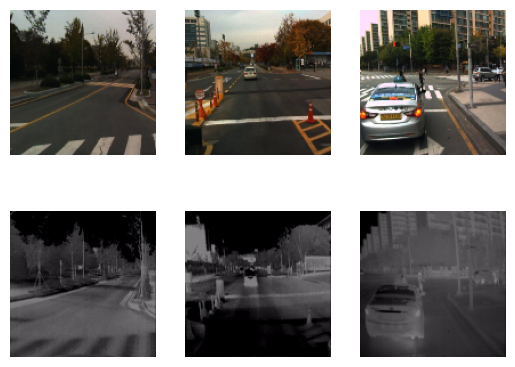

In [3]:
# load the prepared dataset
from numpy import load
from matplotlib import pyplot
# load the dataset
data = load('combined_dataset.npz')
src_images, tar_images = data['arr_0'], data['arr_1']
print('Loaded: ', src_images.shape, tar_images.shape)
# plot source images
n_samples = 3
for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + i)
	pyplot.axis('off')
	pyplot.imshow(src_images[i].astype('uint8'))
# plot target image
for i in range(n_samples):
	pyplot.subplot(2, n_samples, 1 + n_samples + i)
	pyplot.axis('off')
	pyplot.imshow(tar_images[i].astype('uint8'))
pyplot.show()

In [2]:
# Import the necessary libraries
from keras.initializers import RandomNormal

# Set a seed for the RandomNormal initializer
seed_value = 42  # You can use any value for the seed
init = RandomNormal(stddev=0.02, seed=seed_value)

# define the discriminator model
def define_discriminator(image_shape):
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# source image input
	in_src_image = Input(shape=image_shape)
	# target image input
	in_target_image = Input(shape=image_shape)
	# concatenate images channel-wise
	merged = Concatenate()([in_src_image, in_target_image])
	# C64
	d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
	d = LeakyReLU(alpha=0.2)(d)
	# C128
	d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C256
	d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# C512
	d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# second last output layer
	d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# patch output
	d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
	patch_out = Activation('sigmoid')(d)
	# define model
	model = Model([in_src_image, in_target_image], patch_out)
	# compile model
	opt = Adam(lr=0.00002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
	return model

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# define an encoder block
def define_encoder_block(layer_in, n_filters, batchnorm=True):
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# add downsampling layer
	g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	# conditionally add batch normalization
	if batchnorm:
		g = BatchNormalization()(g, training=True)
	# leaky relu activation
	g = LeakyReLU(alpha=0.2)(g)
	return g

# define a decoder block
def decoder_block(layer_in, skip_in, n_filters, dropout=True):
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# add upsampling layer
	g = Conv2DTranspose(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	# add batch normalization
	g = BatchNormalization()(g, training=True)
	# conditionally add dropout
	if dropout:
		g = Dropout(0.5)(g, training=True)
	# merge with skip connection
	g = Concatenate()([g, skip_in])
	# relu activation
	g = Activation('relu')(g)
	return g

# define the standalone generator model
def define_generator(image_shape=(128,128,3)):
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# image input
	in_image = Input(shape=image_shape)
	# encoder model
	e1 = define_encoder_block(in_image, 64, batchnorm=False)
	e2 = define_encoder_block(e1, 128)
	e3 = define_encoder_block(e2, 256)
	e4 = define_encoder_block(e3, 512)
	e5 = define_encoder_block(e4, 512)
	e6 = define_encoder_block(e5, 512)
# 	e7 = define_encoder_block(e6, 512)
	# bottleneck, no batch norm and relu
	b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e6)
	b = Activation('relu')(b)
	# decoder model
# 	d1 = decoder_block(b, e7, 512)
	d2 = decoder_block(b, e6, 512)
	d3 = decoder_block(d2, e5, 512)
	d4 = decoder_block(d3, e4, 512, dropout=False)
	d5 = decoder_block(d4, e3, 256, dropout=False)
	d6 = decoder_block(d5, e2, 128, dropout=False)
	d7 = decoder_block(d6, e1, 64, dropout=False)
	# output
	g = Conv2DTranspose(3, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d7)
	out_image = Activation('tanh')(g)
	# define model
	model = Model(in_image, out_image)
	return model

In [4]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model, image_shape):
	# make weights in the discriminator not trainable
	for layer in d_model.layers:
		if not isinstance(layer, BatchNormalization):
			layer.trainable = False
	# define the source image
	in_src = Input(shape=image_shape)
	# connect the source image to the generator input
	gen_out = g_model(in_src)
	# connect the source input and generator output to the discriminator input
	dis_out = d_model([in_src, gen_out])
	# src image as input, generated image and classification output
	model = Model(in_src, [dis_out, gen_out])
	# compile model
	opt = Adam(lr=0.0002, beta_1=0.5)
	model.compile(loss=['binary_crossentropy', 'mae'], optimizer=opt, loss_weights=[1,100])
	return model

In [5]:
# load and prepare training images
def load_real_samples(filename):
	# load compressed arrays
	data = load(filename)
	# unpack arrays
	X1, X2 = data['arr_0'], data['arr_1']
	# scale from [0,255] to [-1,1]
	X1 = (X1 - 127.5) / 127.5
	X2 = (X2 - 127.5) / 127.5
	return [X1, X2]

In [6]:
# select a batch of random samples, returns images and target
def generate_real_samples(dataset, n_samples, patch_shape):
	# unpack dataset
	trainA, trainB = dataset
	# choose random instances
	ix = randint(0, trainA.shape[0], n_samples)
	# retrieve selected images
	X1, X2 = trainA[ix], trainB[ix]
	# generate 'real' class labels (1)
	y = ones((n_samples, patch_shape, patch_shape, 1))
	return [X1, X2], y

In [7]:
# generate a batch of images, returns images and targets
def generate_fake_samples(g_model, samples, patch_shape):
	# generate fake instance
	X = g_model.predict(samples)
	# create 'fake' class labels (0)
	y = zeros((len(X), patch_shape, patch_shape, 1))
	return X, y

In [8]:
# generate samples and save as a plot and save the model
def summarize_performance(step, g_model, dataset, n_samples=3):
	# select a sample of input images
	[X_realA, X_realB], _ = generate_real_samples(dataset, n_samples, 1)
	# generate a batch of fake samples
	X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
	# scale all pixels from [-1,1] to [0,1]
	X_realA = (X_realA + 1) / 2.0
	X_realB = (X_realB + 1) / 2.0
	X_fakeB = (X_fakeB + 1) / 2.0
	# plot real source images
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + i)
		pyplot.axis('off')
		pyplot.imshow(X_realA[i])
	# plot generated target image
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + n_samples + i)
		pyplot.axis('off')
		pyplot.imshow(X_fakeB[i])
	# plot real target image
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + n_samples*2 + i)
		pyplot.axis('off')
		pyplot.imshow(X_realB[i])
	# save plot to file
	filename1 = 'plot_%06d.png' % (step+1)
	pyplot.savefig(filename1)
	pyplot.close()
	# save the generator model
	filename2 = 'model_%06d.h5' % (step+1)
	g_model.save(filename2)
	print('>Saved: %s and %s' % (filename1, filename2))

In [9]:
def train(d_model, g_model, gan_model, dataset, n_epochs=200, n_batch=5):
    # determine the output square shape of the discriminator
    n_patch = d_model.output_shape[1]
    # unpack dataset
    trainA, trainB = dataset
    # calculate the number of batches per training epoch
    bat_per_epo = int(len(trainA) / n_batch)
    # calculate the number of training iterations
    n_steps = bat_per_epo * n_epochs
    # manually enumerate epochs
    for i in range(n_steps):
        # select a batch of real samples
        [X_realA, X_realB], y_real = generate_real_samples(dataset, n_batch, n_patch)
        # generate a batch of fake samples
        X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)
        # update discriminator for real samples
        d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
        # update discriminator for generated samples
        d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)
        # update the generator
        g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])
        # summarize performance
        print('>%d, d1[%.3f] d2[%.3f] g[%.3f]' % (i+1, d_loss1, d_loss2, g_loss))
        # summarize model performance
        
    summarize_performance(i, g_model, dataset)


In [10]:
import os
from os import listdir
from numpy import asarray
from numpy import savez_compressed
from numpy import load
from numpy import ones
from numpy import zeros
from numpy.random import randint
from numpy import vstack
from matplotlib import pyplot
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Input

from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Activation
from keras.layers import BatchNormalization
from keras.layers import Dropout
from keras.initializers import RandomNormal


In [11]:
# imports
import os
from os import listdir
from numpy import asarray, vstack, ones, zeros, load, savez_compressed
from numpy.random import randint

from matplotlib import pyplot
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Conv2D, Conv2DTranspose, LeakyReLU, Activation, BatchNormalization, Dropout
from keras.initializers import RandomNormal
from keras.layers import Concatenate

# The rest of the code remains unchanged from the provided implementation.
# Make sure to complete the missing parts of the code for a fully functional pix2pix model.


/opt/conda/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


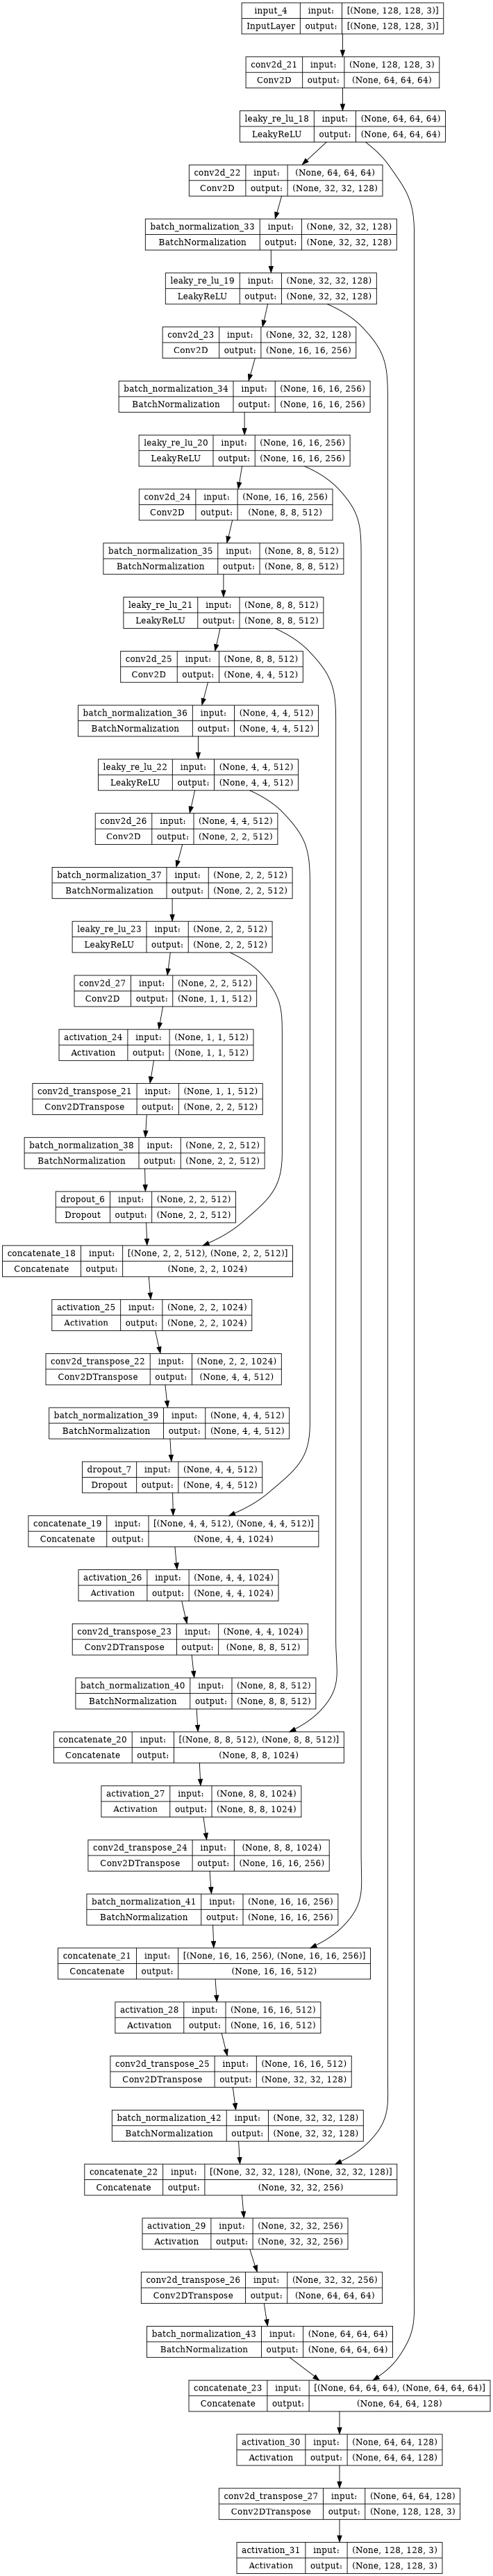

In [17]:

import tensorflow as tf
from tensorflow.keras.utils import plot_model


# Create instances of the generators
generator_x = define_generator() 

# Plot the model for generator_x
plot_model(generator_x, show_shapes=True, dpi=64)


/opt/conda/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


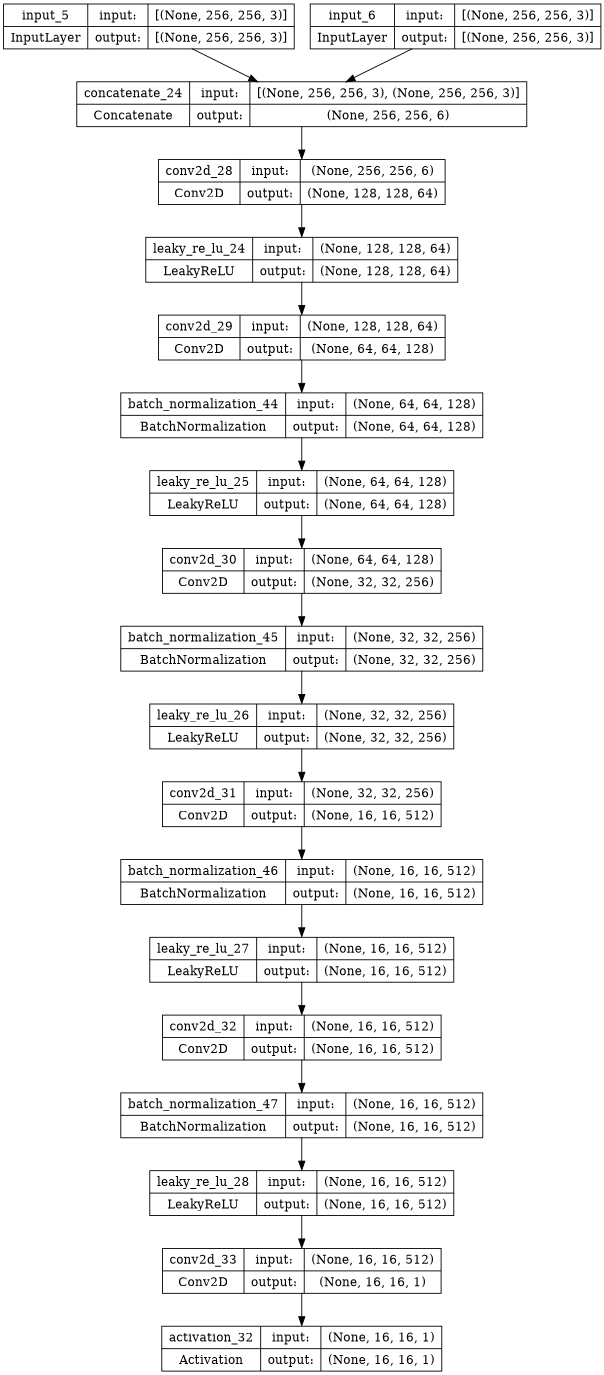

In [23]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model

# Assuming you have already defined the image_shape
image_shape = (256, 256, 3)  # Update with your actual image shape

# Create an instance of the discriminator
discriminator_model = define_discriminator(image_shape)

# Plot the model for the discriminator
plot_model(discriminator_model, show_shapes=True, dpi=64)


In [ ]:
# Load the real samples from the dataset
dataset = load_real_samples('combined_dataset.npz')
print('Loaded', dataset[0].shape, dataset[1].shape)

# Define input shape based on the loaded dataset
image_shape = dataset[0].shape[1:]

# Define the models
d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)

# Define the composite model
gan_model = define_gan(g_model, d_model, image_shape)

# Train the model
train(d_model, g_model, gan_model, dataset)


Loaded (1000, 128, 128, 3) (1000, 128, 128, 3)


/opt/conda/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
2023-11-10 19:43:59.463594: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_7/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1/1 [==============================] - 1s 625ms/step


2023-11-10 19:44:07.438373: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_8/model_7/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


>1, d1[0.337] d2[2.963] g[72.878]
1/1 [==============================] - 0s 21ms/step
>2, d1[0.734] d2[2.046] g[64.101]
1/1 [==============================] - 0s 21ms/step
>3, d1[1.004] d2[1.000] g[49.526]
1/1 [==============================] - 0s 22ms/step
>4, d1[0.564] d2[0.653] g[44.314]
1/1 [==============================] - 0s 23ms/step
>5, d1[0.558] d2[0.460] g[37.832]
1/1 [==============================] - 0s 21ms/step
>6, d1[0.471] d2[0.487] g[26.343]
1/1 [==============================] - 0s 23ms/step
>7, d1[0.414] d2[0.499] g[24.367]
1/1 [==============================] - 0s 23ms/step
>8, d1[0.498] d2[0.477] g[20.087]
1/1 [==============================] - 0s 23ms/step
>9, d1[0.446] d2[0.500] g[19.248]
1/1 [==============================] - 0s 22ms/step
>10, d1[0.465] d2[0.429] g[19.820]
1/1 [==============================] - 0s 22ms/step
>11, d1[0.449] d2[0.424] g[19.334]
1/1 [==============================] - 0s 23ms/step
>12, d1[0.408] d2[0.421] g[18.752]
1/1 [============

# How to Translate Images With a Pix2Pix Model

In [1]:
# load and prepare training images
def load_real_samples(filename):
	# load compressed ararys
	data = load(filename)
	# unpack arrays
	X1, X2 = data['arr_0'], data['arr_1']
	# scale from [0,255] to [-1,1]
	X1 = (X1 - 127.5) / 127.5
	X2 = (X2 - 127.5) / 127.5
	return [X1, X2]

In [54]:
...
# load dataset
[X1, X2] = load_real_samples('combined_dataset.npz')
print('Loaded', X1.shape, X2.shape)

Loaded (1000, 128, 128, 3) (1000, 128, 128, 3)


In [55]:
from keras.models import load_model

...
# load model
model = load_model('/kaggle/input/model2000/model_020000.h5')

In [56]:
...
# select random example
ix = randint(0, len(X1), 1)
src_image, tar_image = X1[ix], X2[ix]

In [57]:
...
# generate image from source
gen_image = model.predict(src_image)

1/1 [==============================] - 0s 393ms/step


2023-11-10 19:32:14.713839: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_4/dropout_2/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


In [58]:
# plot source, generated and target images
def plot_images(src_img, gen_img, tar_img):
	images = vstack((src_img, gen_img, tar_img))
	# scale from [-1,1] to [0,1]
	images = (images + 1) / 2.0
	titles = ['Source', 'Generated', 'Expected']
	# plot images row by row
	for i in range(len(images)):
		# define subplot
		pyplot.subplot(1, 3, 1 + i)
		# turn off axis
		pyplot.axis('off')
		# plot raw pixel data
		pyplot.imshow(images[i])
		# show title
		pyplot.title(titles[i])
	pyplot.show()

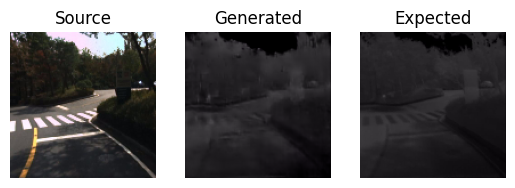

In [59]:
...
# plot all three images
plot_images(src_image, gen_image, tar_image)

In [12]:
from keras.models import load_model
from keras.preprocessing.image import img_to_array, load_img
import numpy as np
import pandas as pd

# Load the trained generator model
generator_model = load_model('/kaggle/input/model2000/model_020000.h5')  # Replace 'model.h5' with the actual filename of your trained generator model

# Define paths to the validation RGB and thermal images
val_rgb_path = '/kaggle/input/testing/Test_samples'
val_thermal_path = '/kaggle/input/rgb_2_thermal/val/val/thermal/'

# Create an output directory for the generated thermal images
output_dir = '/kaggle/working/generated_thermal/'
os.makedirs(output_dir, exist_ok=True)

# Create a DataFrame to store the results
submission_df = pd.DataFrame(columns=['ID', 'RMImg'])

# Function to perform image translation and encoding
def translate_and_encode(model, src_path, dest_path, submission_df):
    for filename in os.listdir(src_path):
        # Load and preprocess the RGB image
        rgb_image = load_img(os.path.join(src_path, filename), target_size=(128, 128))
        rgb_image = img_to_array(rgb_image)
        rgb_image = (rgb_image - 127.5) / 127.5  # Normalize to the range [-1, 1]
        rgb_image = np.expand_dims(rgb_image, axis=0)

        # Generate the corresponding thermal image using the generator model
        generated_thermal = model.predict(rgb_image)

        # Denormalize the generated thermal image
        generated_thermal = 0.5 * generated_thermal + 0.5
        generated_thermal = (generated_thermal*255).astype(int)  # Convert to integers
        # Encode the thermal image in Row-Major order
        encoded_thermal = generated_thermal.flatten().tolist()

        # Save the encoded thermal image to the DataFrame
        submission_df = pd.concat([submission_df, pd.DataFrame({'ID': [filename], 'RMImg': [encoded_thermal]})], ignore_index=True)

    return submission_df

# Perform image translation and encoding on the validation set
submission_df = translate_and_encode(generator_model, val_rgb_path, output_dir, submission_df)

# Save the DataFrame to a CSV file
submission_df.to_csv('/kaggle/working/submission.csv', index=False)


2023-11-12 12:04:02.083613: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_4/dropout_2/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1/1 [==============================] - 0s 19ms/step


In [62]:
from IPython.display import FileLink

FileLink(r'submission.csv')


/kaggle/working/submission.csv

# Generated photos

* photos given by sir

1/1 [==============================] - 0s 344ms/step


2023-11-12 12:24:48.638158: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_4/dropout_2/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


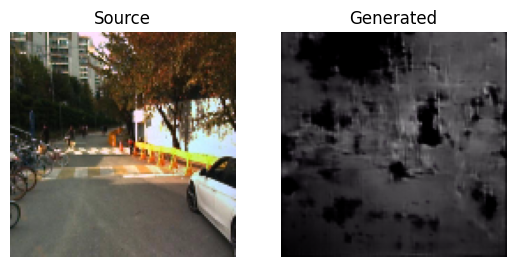

1/1 [==============================] - 0s 20ms/step


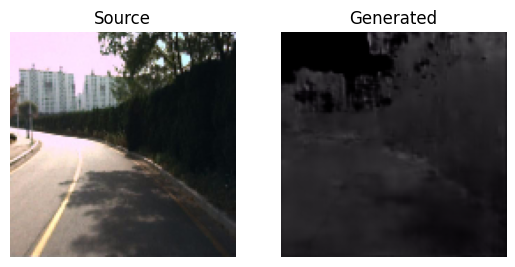

1/1 [==============================] - 0s 20ms/step


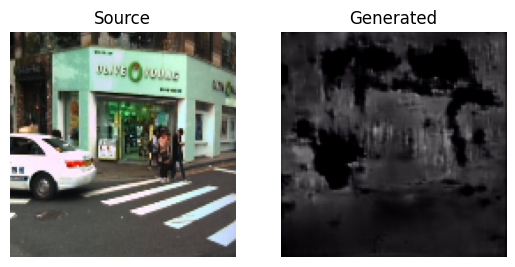

1/1 [==============================] - 0s 20ms/step


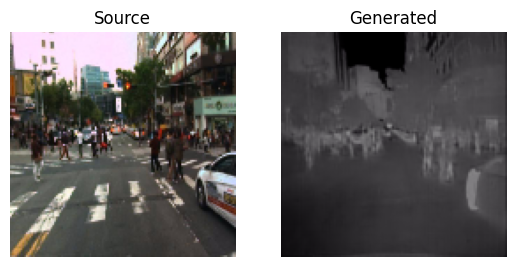

1/1 [==============================] - 0s 19ms/step


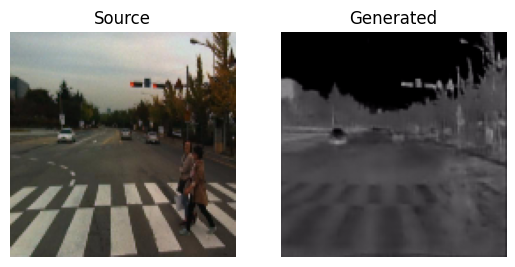

1/1 [==============================] - 0s 26ms/step


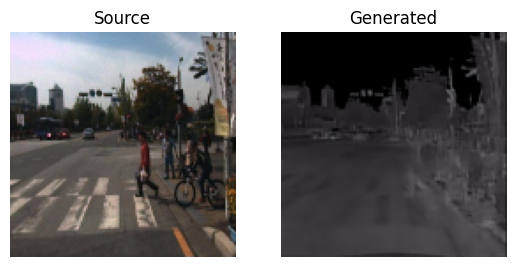

In [32]:
import os
from keras.preprocessing.image import load_img
from keras.models import load_model
from matplotlib import pyplot
import tensorflow as tf

# Plot source and generated images
def plot_images(src_img, gen_img):
    images = [src_img, gen_img]
    # Scale from [-1,1] to [0,1]
    images = [(img + 1) / 2.0 for img in images]
    titles = ['Source', 'Generated']
    # Plot images row by row
    for i in range(len(images)):
        # Define subplot
        pyplot.subplot(1, len(images), 1 + i)
        # Turn off axis
        pyplot.axis('off')
        # Plot raw pixel data
        pyplot.imshow(images[i])
        # Show title
        pyplot.title(titles[i])
    pyplot.show()

# Directory containing source images
src_path = '/kaggle/input/testing/Test_samples'

# Load the pre-trained model
model = load_model('/kaggle/input/model2000/model_020000.h5')

# Iterate over each file in the directory
for filename in os.listdir(src_path):
    # Load and preprocess the RGB image
    rgb_image = load_img(os.path.join(src_path, filename), target_size=(128, 128))
    rgb_image = tf.keras.preprocessing.image.img_to_array(rgb_image)
    rgb_image = (rgb_image - 127.5) / 127.5  # Scale to [-1, 1]
    rgb_image = tf.expand_dims(rgb_image, axis=0)

    # Generate images using the model
    gen_image = model.predict(rgb_image)

    # Plot the source and generated images
    plot_images(rgb_image[0], gen_image[0])
